In [6]:
import pandas as pd

df = pd.read_csv("funnelanalysis.csv")
df.head()

,user_id,step,timestamp
0,U026,details_filled,2026-07-20 04:19:00
1,U017,signup_started,2026-07-20 04:16:00
2,U042,visited_site,2026-07-20 04:07:00
3,U026,signup_started,2026-07-20 04:02:00
4,U066,signup_started,2026-07-20 03:46:00


In [7]:
df.head()

,user_id,step,timestamp
0,U026,details_filled,2026-07-20 04:19:00
1,U017,signup_started,2026-07-20 04:16:00
2,U042,visited_site,2026-07-20 04:07:00
3,U026,signup_started,2026-07-20 04:02:00
4,U066,signup_started,2026-07-20 03:46:00


In [10]:
df.columns

Index(['user_id', 'step', 'timestamp'], dtype='object')

In [11]:
stage = df.groupby("step")["user_id"].nunique()

stage

,user_id
step,
details_filled,96
email_verified,52
purchase_completed,44
signup_started,150
visited_site,200


In [12]:
conversion = stage / stage.shift(1) * 100

conversion

,user_id
step,
details_filled,NaN
email_verified,54.166667
purchase_completed,84.615385
signup_started,340.909091
visited_site,133.333333


In [13]:
conversion.iloc[0] = 100

conversion



,user_id
step,
details_filled,100.000000
email_verified,54.166667
purchase_completed,84.615385
signup_started,340.909091
visited_site,133.333333


In [14]:
drop = stage.shift(1) - stage

drop

,user_id
step,
details_filled,NaN
email_verified,44.0
purchase_completed,8.0
signup_started,-106.0
visited_site,-50.0


In [15]:
drop.idxmax()

'email_verified'

In [16]:
print("Stage:", drop.idxmax())
print("Users Dropped:", drop.max())

Stage: email_verified
Users Dropped: 44.0


In [17]:
result = pd.DataFrame({
    "Users": stage,
    "Conversion %": conversion,
    "Drop Off": drop
})

result

,Users,Conversion %,Drop Off
step,,,
details_filled,96,100.000000,NaN
email_verified,52,54.166667,44.0
purchase_completed,44,84.615385,8.0
signup_started,150,340.909091,-106.0
visited_site,200,133.333333,-50.0


In [26]:
import matplotlib.pyplot as plt

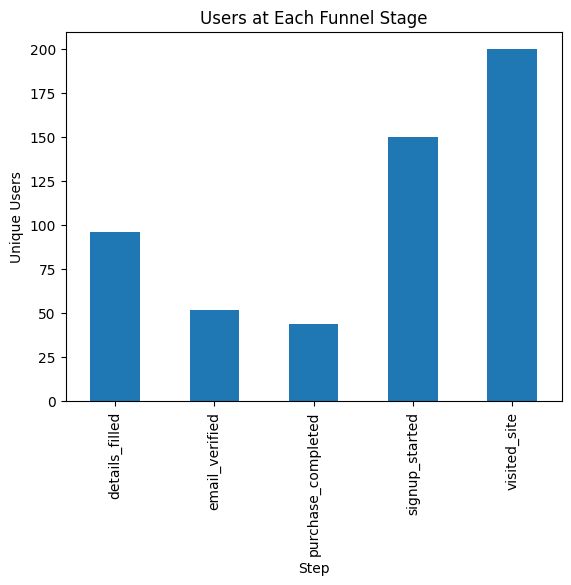

In [27]:
stage.plot(kind="bar")

plt.title("Users at Each Funnel Stage")
plt.xlabel("Step")
plt.ylabel("Unique Users")

plt.show()

In [32]:
result.reset_index(inplace=True)

result

,index,step,Users,Conversion %,Drop Off
0,0,details_filled,96,100.000000,NaN
1,1,email_verified,52,54.166667,44.0
2,2,purchase_completed,44,84.615385,8.0
3,3,signup_started,150,340.909091,-106.0
4,4,visited_site,200,133.333333,-50.0


In [33]:

result.to_excel("Funnel_Output.xlsx", index=False)


In [35]:
!pip install plotly

In [36]:
import plotly.graph_objects as go
print(stage)

step
details_filled         96
email_verified         52
purchase_completed     44
signup_started        150
visited_site          200
Name: user_id, dtype: int64


In [37]:
import plotly.graph_objects as go

fig = go.Figure(go.Funnel(
    y=stage.index.tolist(),
    x=stage.values.tolist()
))

fig.update_layout(
    title="Funnel Drop-off Analysis"
)

fig.show()